# 1. Importar librerías

In [4]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
sys.path.append(project_root)

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

from src.preprocessing import build_preprocessing_pipeline
from src.config import DATA_PATH, PROCESSED_DATA_PATH


# 2. Cargar Dataset

df = pd.read_csv(DATA_PATH)
df.head()

# 3. Preparar datos y preprocesamiento

In [5]:
preprocessor = build_preprocessing_pipeline()
df_processed = pd.read_csv(PROCESSED_DATA_PATH)

Dataset guardado en: /Users/enmanueldeoleo/Pontia/ML-Practica-Only/data/processed/processed_dataset.csv


In [6]:
# Separar variables
X = df_processed.drop("is_canceled", axis=1)
y = df_processed["is_canceled"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4.Entrenar los 5 modelos (solo para evaluación visual)

In [7]:
modelos = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Neural Network": MLPClassifier(max_iter=300)
}

modelos_entrenados = {}

for nombre, modelo in modelos.items():
    clf = Pipeline([
        ("preprocessor", preprocessor),
        ("model", modelo)
    ])
    clf.fit(X_train, y_train)
    modelos_entrenados[nombre] = clf

print("Modelos entrenados correctamente.")



Modelos entrenados correctamente.


# 5. Curva ROC comparativa

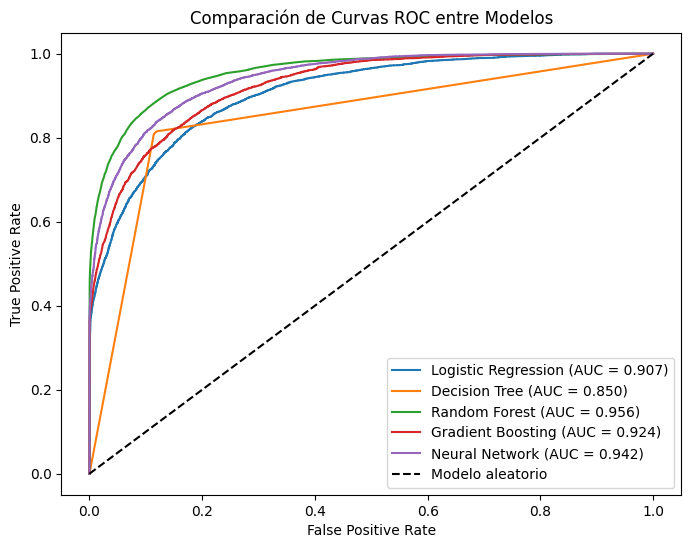

In [8]:
plt.figure(figsize=(8,6))

for nombre, modelo in modelos_entrenados.items():
    y_prob = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{nombre} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], "k--", label="Modelo aleatorio")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Comparación de Curvas ROC entre Modelos")
plt.legend()
plt.savefig("../../outputs/roc_comparativa.png", dpi=300, bbox_inches="tight")

plt.show()




# 6. Matriz de confusión del mejor modelo (Random Forest)

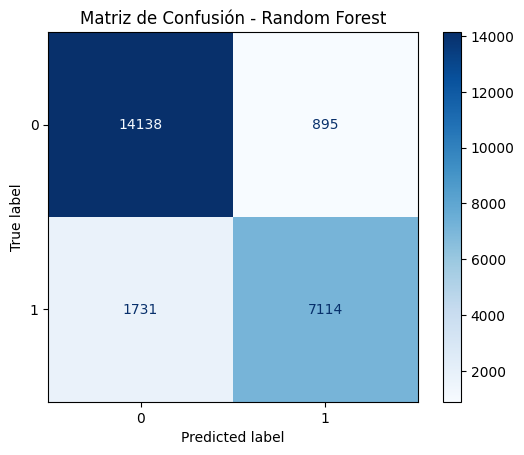

In [9]:
mejor_modelo = modelos_entrenados["Random Forest"]

y_pred = mejor_modelo.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Matriz de Confusión - Random Forest")
plt.savefig("../../outputs/matriz_confusion.png", dpi=300, bbox_inches="tight")

plt.show()



# 7. Importancia de variables

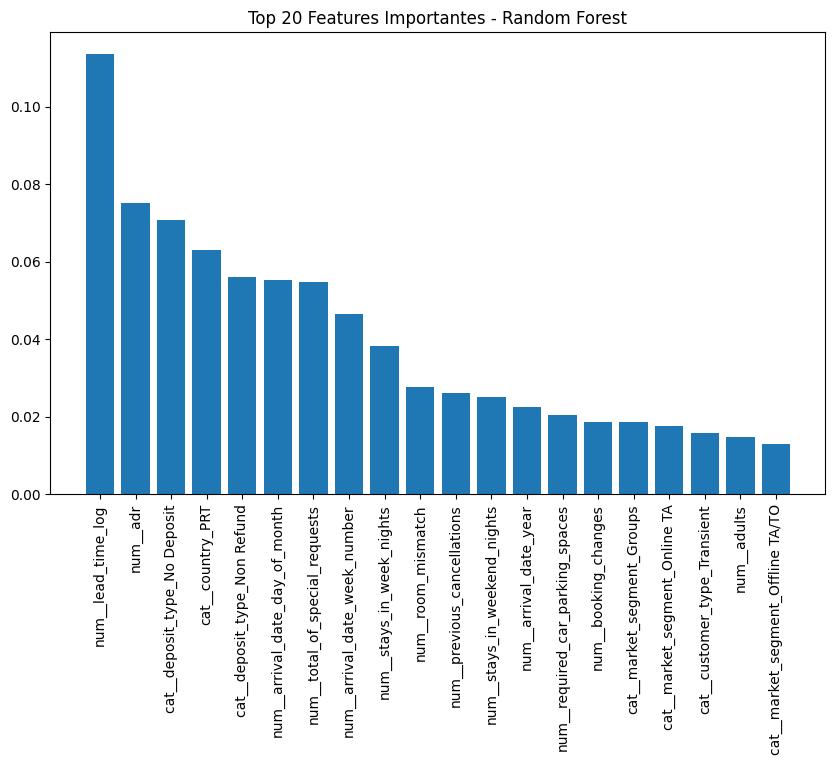

In [10]:
import numpy as np

modelo_rf = modelos_entrenados["Random Forest"]

# Obtener nombres de columnas tras el preprocesamiento
feature_names = modelo_rf.named_steps["preprocessor"].get_feature_names_out()

importances = modelo_rf.named_steps["model"].feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.bar(range(20), importances[indices][:20])
plt.xticks(range(20), feature_names[indices][:20], rotation=90)
plt.title("Top 20 Features Importantes - Random Forest")
plt.savefig("../../outputs/feature_importances.png", dpi=300, bbox_inches="tight")

plt.show()



# 8. Importancia de varibles solo en caso de que el modelo lo soporte, como Random Forest o Gradient Boosting nada mas.

In [11]:
import joblib
import numpy as np
import pandas as pd

# Cargar el mejor modelo entrenado por el pipeline
best_model = joblib.load(os.path.join(project_root, "models", "best_model.pkl"))

# Extraer modelo y preprocesador
model = best_model.named_steps["model"]
preprocessor = best_model.named_steps["preprocessor"]

# Obtener nombres de columnas numéricas
num_features = preprocessor.transformers_[0][2]

# Obtener nombres de columnas categóricas codificadas
cat_features = preprocessor.transformers_[1][2]
encoded_cols = preprocessor.named_transformers_["cat"]["encoder"].get_feature_names_out(cat_features)

# Unir todas las columnas finales
all_features = list(num_features) + list(encoded_cols)

# Importancias del modelo (solo funciona si es árbol, RF, GB, etc.)
importances = model.feature_importances_

# Crear dataframe ordenado
feat_imp = pd.DataFrame({
    "feature": all_features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feat_imp.head(20)



,feature,importance
17,lead_time_log,0.110224
13,adr,0.075259
224,deposit_type_Non Refund,0.067890
223,deposit_type_No Deposit,0.066840
168,country_PRT,0.061420
15,total_of_special_requests,0.055628
2,arrival_date_day_of_month,0.054667
1,arrival_date_week_number,0.047180
4,stays_in_week_nights,0.036881
16,room_mismatch,0.030124


# 9. Tabla comparativa de los modelos y sus resultados.

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

resultados = []

for nombre, modelo in modelos_entrenados.items():
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    resultados.append({
        "Modelo": nombre,
        "Accuracy":  round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall":    round(recall_score(y_test, y_pred), 4),
        "F1-Score":  round(f1_score(y_test, y_pred), 4),
        "ROC-AUC":   round(roc_auc_score(y_test, y_prob), 4),
    })

results_df = pd.DataFrame(resultados).set_index("Modelo")
results_df.sort_values("ROC-AUC", ascending=False)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modelo,,,,,
Random Forest,0.8900,0.8883,0.8043,0.8442,0.9565
Neural Network,0.8622,0.7949,0.8464,0.8198,0.9419
Gradient Boosting,0.8482,0.8320,0.7395,0.7830,0.9240
Logistic Regression,0.8284,0.8149,0.6945,0.7499,0.9065
Decision Tree,0.8572,0.8056,0.8099,0.8078,0.8495


# Conclusiones De evaluación de modelos:

## Comparación de modelos (Curva ROC)
Los 5 modelos fueron entrenados y evaluados sobre el mismo conjunto de test (20% del dataset).
El modelo con mejor resultado (de ROC-AUC) es **Random Forest** 0.95. Seguido por la  **Red Neuronal** 0.94

## Variables más influyentes (best_model.pkl)
De acuerdo al análisis de importancia del mejor modelo guardado:

| Variable | Importancia | Interpretación |
|---|---|---|
| `lead_time_log` | 11.0% | Más anticipación → más probabilidad de cancelar |
| `adr` | 7.5% | El precio influye en la decisión de cancelar |
| `deposit_type_Non Refund` | 6.8% | Contraintuitivo — pagan sin reembolso pero igual cancelan |
| `deposit_type_No Deposit` | 6.7% | Sin penalización económica, cancelar no cuesta nada |
| `country_PRT` | 6.1% | Portugal es el mercado con mayor tasa de cancelación (56.6%) |
| `total_of_special_requests` | 5.6% | Más peticiones = más comprometido = menos cancelaciones |
| `room_mismatch` | 3.0% | Habitación diferente = posiblemente upgrade = menos cancelaciones |


## Validación con el EDA
Los hallazgos del modelo confirman lo observado en el EDA inicial:
- `lead_time` fue el primer predictor identificado visualmente
- `deposit_type` mostró el comportamiento raro de Non Refund
- `country_PRT` coincide con la tasa del 56.6% observada en el EDA